In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.52MB/s]

Training Images : 60000
Testing Images  : 10000


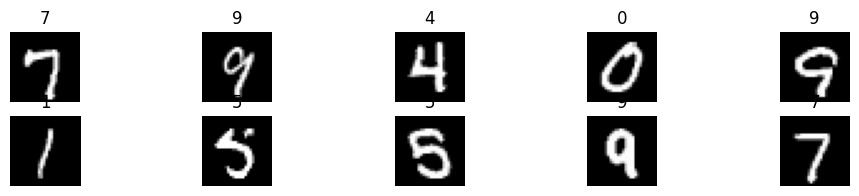

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,2))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()

In [6]:
class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64)

        )

        self.decoder = nn.Sequential(

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),

            nn.Sigmoid()

        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        reconstruction = reconstruction.view(-1,1,28,28)

        return reconstruction

In [7]:
model = AutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [8]:
epochs = 10

loss_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,_ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.6f}"
    )

Epoch 1/10 Loss: 0.051189
Epoch 2/10 Loss: 0.024663
Epoch 3/10 Loss: 0.018635
Epoch 4/10 Loss: 0.015307
Epoch 5/10 Loss: 0.013240
Epoch 6/10 Loss: 0.011777
Epoch 7/10 Loss: 0.010638
Epoch 8/10 Loss: 0.009789
Epoch 9/10 Loss: 0.009091
Epoch 10/10 Loss: 0.008507


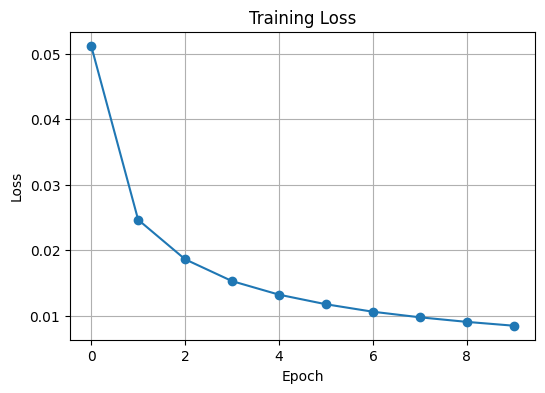

In [9]:
plt.figure(figsize=(6,4))

plt.plot(loss_history, marker="o")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [10]:
model.eval()

images, labels = next(iter(test_loader))

image = images.to(device)

start = time.time()

with torch.no_grad():

    reconstruction = model(image)

end = time.time()

print("Inference Time:", end-start, "seconds")

Inference Time: 0.04442620277404785 seconds


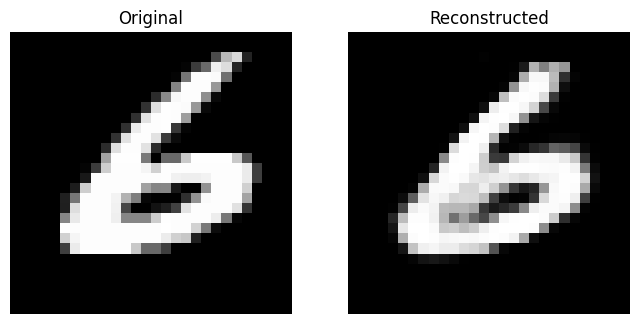

In [11]:
original = image.cpu().squeeze().numpy()

reconstructed = reconstruction.cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.imshow(original,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(reconstructed,cmap="gray")

plt.title("Reconstructed")

plt.axis("off")

plt.show()

In [12]:
mse = np.mean((original-reconstructed)**2)

print("Reconstruction Error (MSE):", mse)

Reconstruction Error (MSE): 0.009469132


In [13]:
with torch.no_grad():

    latent = model.encoder(image)

print("Latent Shape:", latent.shape)

print(latent)

Latent Shape: torch.Size([1, 64])
tensor([[-4.8227,  0.3980, -1.4625, -0.6035,  4.3542, -3.4387,  4.3832,  6.7349,
          5.9002, -2.2066, -5.6374, -4.8849,  0.8249,  3.3270,  0.3935,  1.8980,
         -3.2921, 10.4238, -1.9214, -7.6237, -1.3648,  4.6170,  2.7157, -1.8418,
         -0.5958,  3.8369,  3.4752,  2.1212, -0.5313, -1.0057, -4.5967,  2.9898,
         -4.1239,  1.4787, -0.2042, -4.9168, -1.7713, -0.6654,  0.2711, -5.7988,
         -1.2049,  4.1661, -1.3060,  0.3613, -3.8288,  1.8294, -1.6266,  1.3477,
         10.5278, -3.0490, -0.0714,  0.3061, -4.2206,  2.6199, -5.9377, -2.2424,
         -6.2179,  3.4116, -0.0641,  1.0608, -0.5096, -5.4177, -1.8361, -2.8643]],
       device='cuda:0')


In [14]:
torch.save(model.state_dict(),"autoencoder_mnist.pth")

print("Model saved successfully.")

Model saved successfully.
